In [124]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
base_path = Path(".") # change to path folder with data 


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.

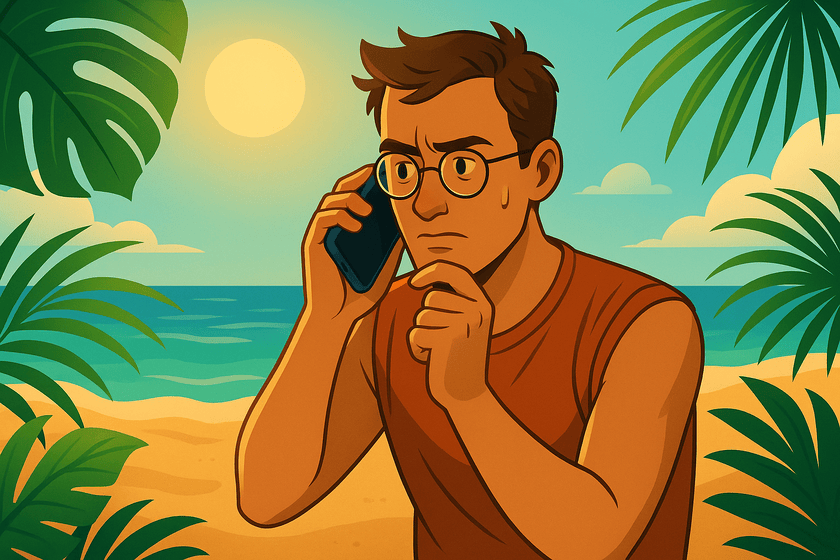

(*AI-generated image*)


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


In [125]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [126]:
titanic_df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

In [127]:
titanic_df['Cabin'].str[0].unique()

<StringArray>
[nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T']
Length: 9, dtype: str

# 1 oczyszczanie datasetu

#### a) Analiza zbioru danych

In [128]:
def missing_values(df):
    count = df.isnull().sum()
    percentage = (count / df.shape[0]) * 100

    result = pd.concat([count, percentage], axis=1)
    result.columns = ['missing values', '%']
    return result

report = missing_values(titanic_df)
print(report)

          missing values          %
Survived               0   0.000000
Pclass                 0   0.000000
Name                   0   0.000000
Sex                    0   0.000000
Age                  177  19.865320
SibSp                  0   0.000000
Parch                  0   0.000000
Ticket                 0   0.000000
Fare                  98  10.998878
Cabin                687  77.104377
Embarked               2   0.224467


#### Wnioski i decyzje
- Survived, Pclass, Sex, SibSp, Parch, Ticket - brak ubytków
- Age - zamieniamy na medianę odpowiadającą Pclass oraz płci
- Fare - zamieniamy na medianę odpowiadającej Pclass
- Cabin - zamieniamy na HasCabin (binarnie)
- Embarked - uzupełniamy za pomocą dominanty

#### b) Implementacja zmian 

In [129]:
# age
titanic_df['Age'] = titanic_df.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
titanic_df['Age'] = titanic_df['Age'].round().astype(int)

# fare
titanic_df['Fare'] = titanic_df.groupby('Pclass')['Fare'].transform(lambda x: x.fillna(x.median()))

# cabin
titanic_df['HasCabin'] = titanic_df['Cabin'].notna().astype(int)
titanic_df.drop(columns=['Cabin'], inplace=True)

# embarked
embarked_mode = titanic_df['Embarked'].mode()[0]
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(embarked_mode)

# test
report = missing_values(titanic_df)
print(report)

          missing values    %
Survived               0  0.0
Pclass                 0  0.0
Name                   0  0.0
Sex                    0  0.0
Age                    0  0.0
SibSp                  0  0.0
Parch                  0  0.0
Ticket                 0  0.0
Fare                   0  0.0
Embarked               0  0.0
HasCabin               0  0.0


# 2 wzbogacanie o kolumny

Dodanie kolumny 'title' na podstawie kolumny 'Name'

In [130]:
title_mapping = {
    'Mr': 'Mr',
    
    'Miss': 'Miss',
    'Mlle': 'Miss',
    'Ms': 'Miss',
    
    'Mrs': 'Mrs',
    'Mme': 'Mrs',
    
    'Master': 'Master',
    
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Major': 'Rare',
    'Capt': 'Rare',
    'Sir': 'Rare',
    'Lady': 'Rare',
    'the Countess': 'Rare',
    'Don': 'Rare',
    'Jonkheer': 'Rare',
    'Dona': 'Rare'
}

titanic_df['Title'] = titanic_df['Name'].str.extract(r',\s*([^\.]+)\.', expand=False)   # Nazwisko Tytuł Imiona
titanic_df['Title'] = titanic_df['Title'].map(title_mapping).fillna('Rare')

print(titanic_df.columns)

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked', 'HasCabin', 'Title'],
      dtype='str')


Dodanie kolumny FamilySize, mniejsze rodziny (2-4 osoby) miały największą szansę na przetrwanie

In [131]:
titanic_df['FamilySize'] = titanic_df['SibSp'] + titanic_df['Parch'] + 1

print(titanic_df.columns)

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked', 'HasCabin', 'Title', 'FamilySize'],
      dtype='str')


# 3 Outliery

In [132]:
print(titanic_df[['Age', 'Fare', 'FamilySize']].skew())

Age           0.533417
Fare          4.882623
FamilySize    2.727441
dtype: float64


Detekcja outlierów ciągłych

In [133]:
continuous_features = ['Age', 'Fare']
for col in continuous_features:
    q25 = titanic_df[col].quantile(0.25)
    q75 = titanic_df[col].quantile(0.75)
    iqr = q75 - q25
    outliers = titanic_df[(titanic_df[col] < q25 - 1.5 * iqr) | (titanic_df[col] > q75 + 1.5 * iqr)][col]
    
    count = len(outliers)
    if count > 0:
        print(f"'{col}': {count} obiektów ({count / len(titanic_df) * 100:.1f}%). Zakres: [{outliers.min():.1f}, {outliers.max():.1f}]")

'Age': 34 obiektów (3.8%). Zakres: [0.0, 80.0]
'Fare': 105 obiektów (11.8%). Zakres: [66.6, 512.3]


Detekcja outlierów dyskretyncyh

In [134]:
count_features = ['FamilySize', 'SibSp', 'Parch']
for col in count_features:
    dist = titanic_df[col].value_counts(normalize=True) * 100
    rare_classes = dist[dist < 1.0]
    if not rare_classes.empty:
        rare_values = rare_classes.index.tolist()
        print(f"'{col}': Wartości występujące u <1% pasażerów: {rare_values}")

'FamilySize': Wartości występujące u <1% pasażerów: [11, 8]
'SibSp': Wartości występujące u <1% pasażerów: [8, 5]
'Parch': Wartości występujące u <1% pasażerów: [5, 3, 4, 6]


#### Komentarz i decyzje analityczne
* **Decyzja o outlierach:** Metoda IQR dla zmiennych ciągłych wyłapuje astronomiczne ceny biletów (najdroższe apartamenty). Rzadkie zjawiska w zmiennych dyskretnych wyłapują wielodzietne rodziny. Z inżynierskiego punktu widzenia są to kluczowe zjawiska brzegowe w kontekście katastrofy, a nie szum sprzętowy matrycy. **Decyzja: Zostawiamy wartości skrajne w zbiorze, nie wykonujemy przycinania (clippingu), ponieważ niosą kluczowy sygnał predykcyjny.** Zamiast szukać sztucznych outlierów w kolumnie `Cabin`, wprowadzono zero-jedynkową flagę `HasCabin`.

# 4 Wizualizacje danych

In [135]:
print(titanic_df.skew(numeric_only=True))

Survived      0.478523
Pclass       -0.630548
Age           0.533417
SibSp         3.695352
Parch         2.749117
Fare          4.882623
HasCabin      1.292367
FamilySize    2.727441
dtype: float64


Widzimy asymetrię prawostronne w cenie biletu (Fare) oraz w wielkości rodziny (FamilySize). 

Wniosek: bogaci pasażerowie oraz duże rodziny to zdecydowana mniejszość.

In [136]:
print(titanic_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Name        891 non-null    str    
 3   Sex         891 non-null    str    
 4   Age         891 non-null    int64  
 5   SibSp       891 non-null    int64  
 6   Parch       891 non-null    int64  
 7   Ticket      891 non-null    str    
 8   Fare        891 non-null    float64
 9   Embarked    891 non-null    str    
 10  HasCabin    891 non-null    int64  
 11  Title       891 non-null    str    
 12  FamilySize  891 non-null    int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 90.6 KB
None


/tmp/ipykernel_8194/3987590034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic_df, x=col, y='Survived', palette='Set2', ax=axes[i])
/tmp/ipykernel_8194/3987590034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic_df, x=col, y='Survived', palette='Set2', ax=axes[i])
/tmp/ipykernel_8194/3987590034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic_df, x=col, y='Survived', palette='Set2', ax=axes[i])
/tmp/ipykernel_8194/3987590034.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is d

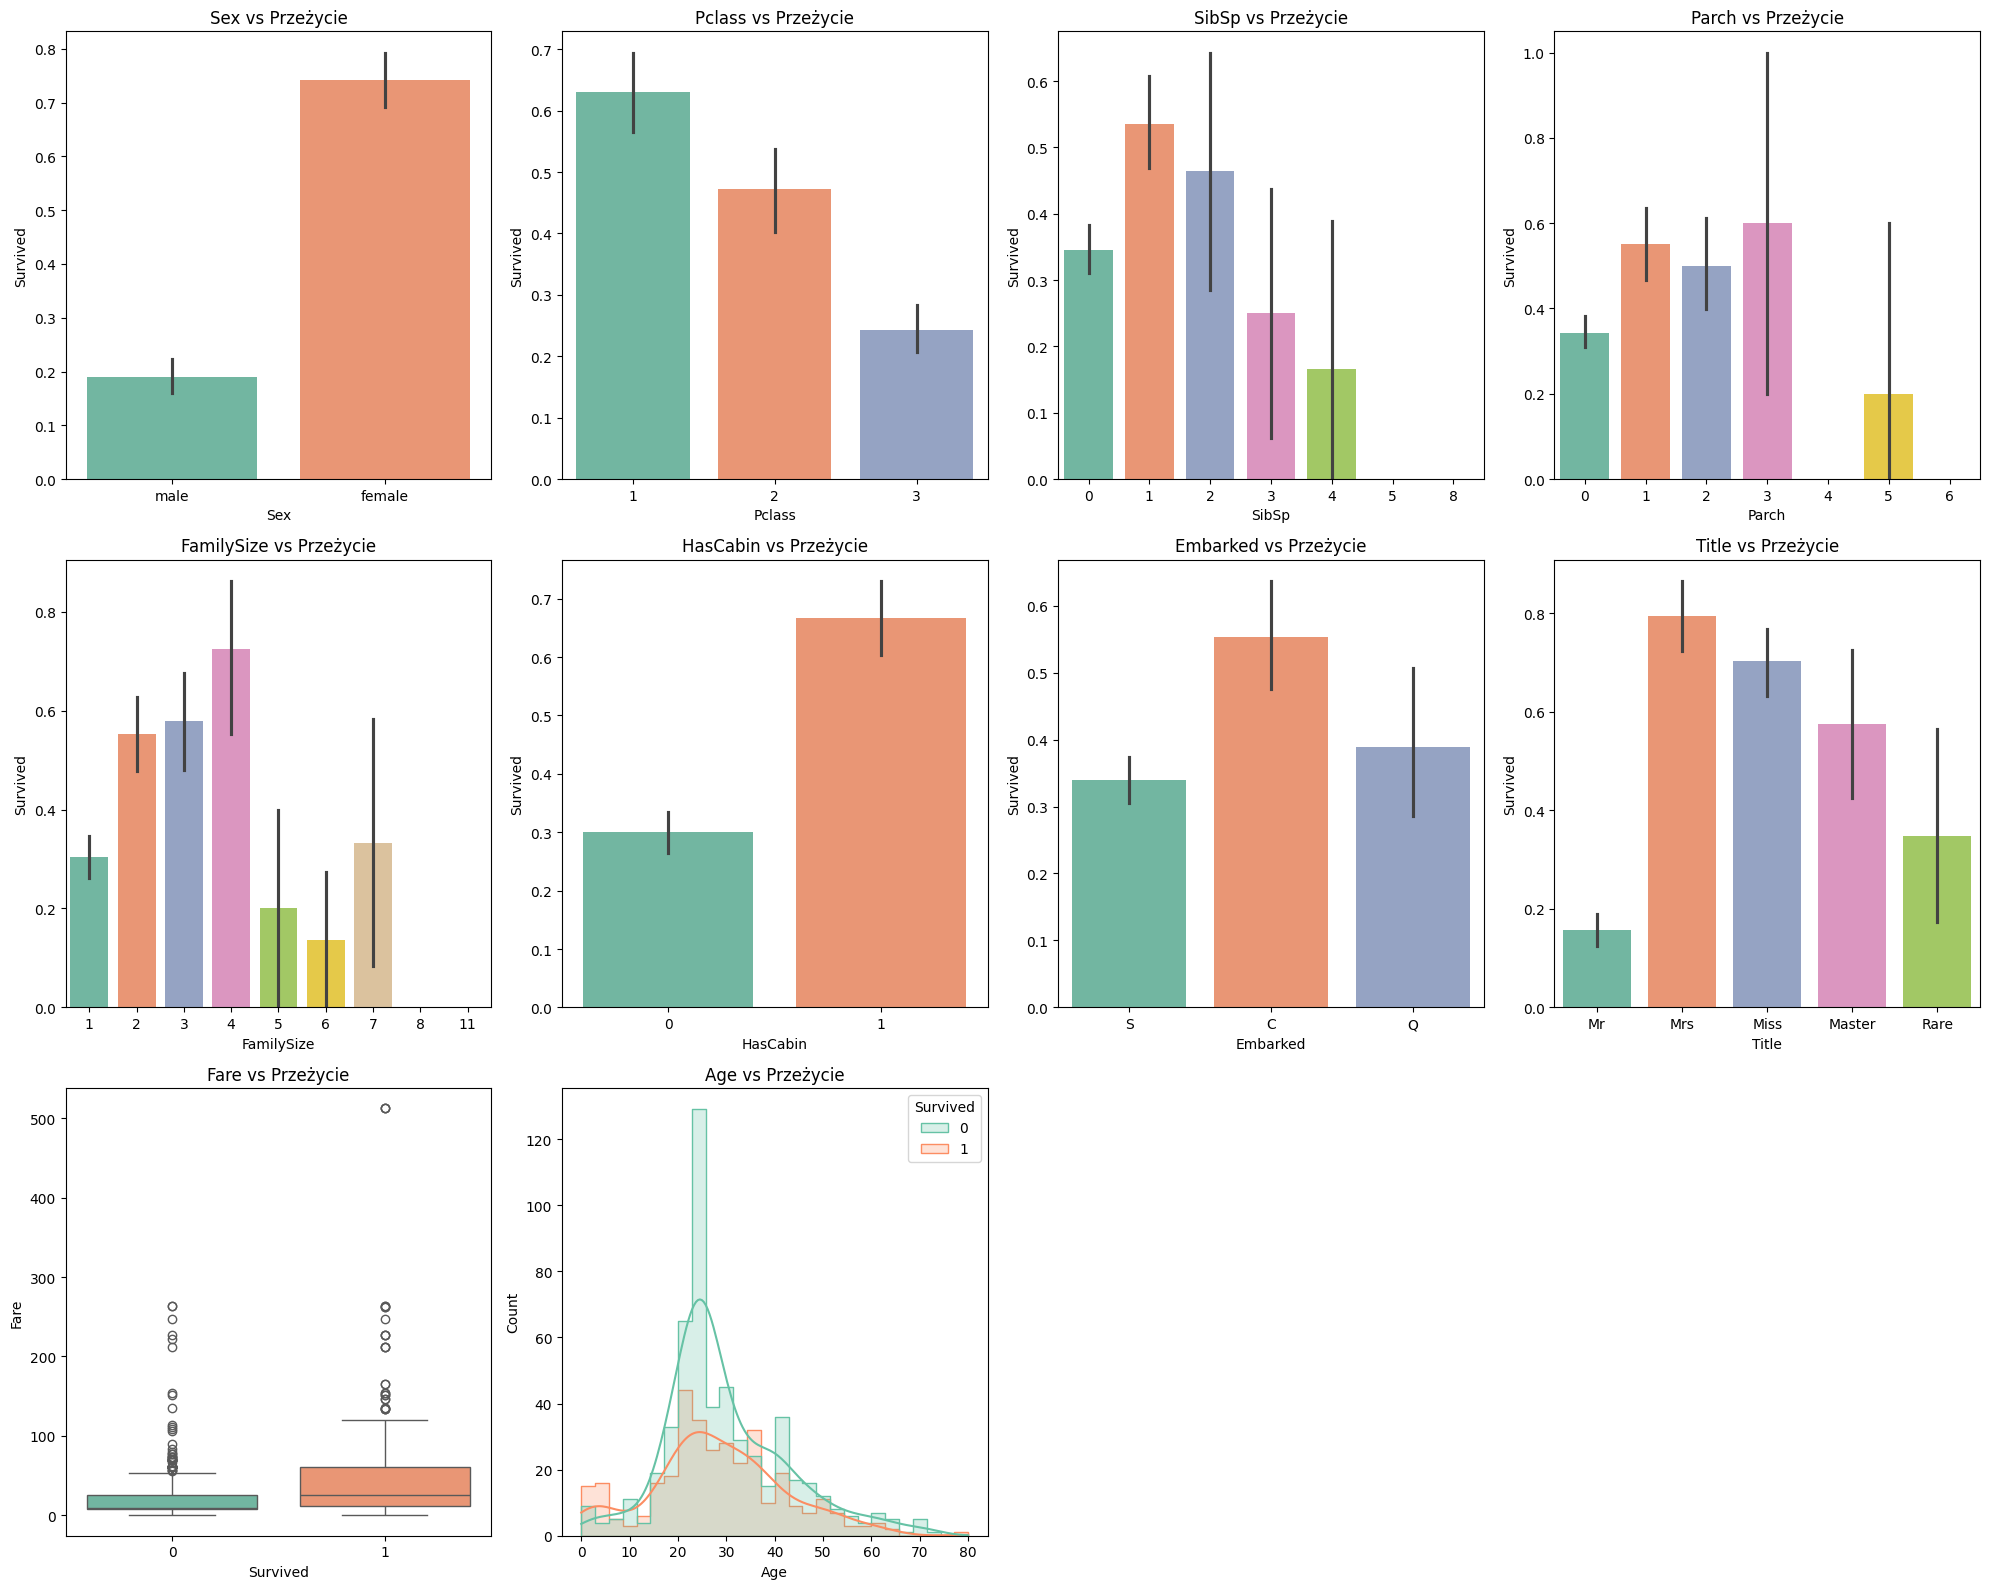

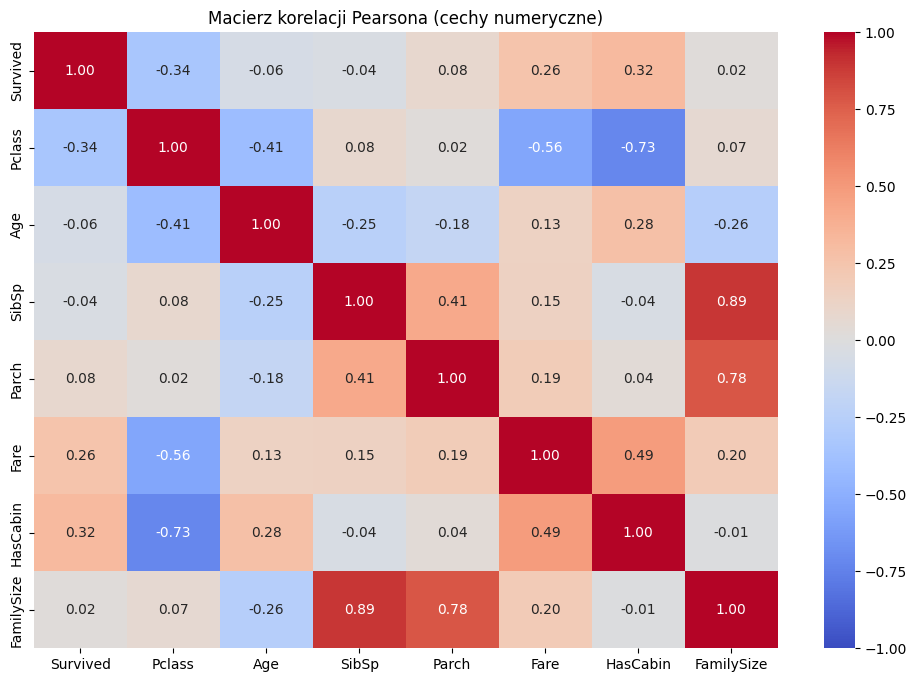

In [137]:
fig, axes = plt.subplots(3, 4, figsize=(20, 16))
axes = axes.flatten()

categorical_features = ['Sex', 'Pclass', 'SibSp', 'Parch', 'FamilySize', 'HasCabin', 'Embarked', 'Title']

for i, col in enumerate(categorical_features):
    sns.barplot(data=titanic_df, x=col, y='Survived', palette='Set2', ax=axes[i])
    axes[i].set_title(f'{col} vs Przeżycie')

sns.boxplot(data=titanic_df, x='Survived', y='Fare', palette='Set2', ax=axes[8])
axes[8].set_title('Fare vs Przeżycie')

sns.histplot(data=titanic_df, x='Age', hue='Survived', kde=True, element='step', common_norm=False, palette='Set2', ax=axes[9])
axes[9].set_title('Age vs Przeżycie')

axes[10].axis('off')
axes[11].axis('off')

plt.tight_layout()
plt.show()


plt.figure(figsize=(12, 8))
sns.heatmap(titanic_df.corr(numeric_only=True), cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title('Macierz korelacji Pearsona (cechy numeryczne)')
plt.show()

#### Wnioski z wizualizacji
- FamilySize: Mniejsze rodziny (2-4 osobowe) miały większy wskaźnik przeżywalności, powyżej 50% w porównaniu do innych grup (single 30%).
- HasCabin: Osoby z brakiem rekordu kabiny w baziemiały szansę na przetrwanie na poziomie 30%, gdy osoby z przypisaną kabiną ponad 65%.

# 5 Kodowanie

Za duża ilość unikalnych rekordów w kolumnach Name i Ticket

In [138]:
titanic_df.drop(columns=['Name', 'Ticket'], inplace=True)

Mapowanie płci:
- male = 0
- female = 1

In [139]:
titanic_df['Sex'] = titanic_df['Sex'].map({'male': 0, 'female': 1})

One-Hot encoding dla miasta startowego, cabin (czyli u nas pokładu) oraz tytułu

In [140]:
categorical_cols = ['Embarked', 'Title']
titanic_df = pd.get_dummies(
    titanic_df, 
    columns=categorical_cols, 
    drop_first=True, 
    dtype=int
)

In [141]:
print(titanic_df.info())
print(titanic_df.head())

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 1 to 891
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    int64  
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   HasCabin    891 non-null    int64  
 8   FamilySize  891 non-null    int64  
 9   Embarked_Q  891 non-null    int64  
 10  Embarked_S  891 non-null    int64  
 11  Title_Miss  891 non-null    int64  
 12  Title_Mr    891 non-null    int64  
 13  Title_Mrs   891 non-null    int64  
 14  Title_Rare  891 non-null    int64  
dtypes: float64(1), int64(14)
memory usage: 104.5 KB
None
             Survived  Pclass  Sex  Age  SibSp  Parch     Fare  HasCabin  \
PassengerId                                                                

Typy danych są teraz poprawne i logiczne